# Eye-tracking descriptives: ocular activity, IRASA, and velocity peaks

This notebook demonstrates a basic workflow for extracting descriptive measures from eye-tracking data recorded with VPixx.

The workflow includes:

1. loading VPixx eye-tracking data,
2. converting gaze coordinates to radians,
3. detecting and interpolating blinks,
4. selecting the better eye,
5. running IRASA on gaze and pupil signals,
6. computing velocity-based ocular activity measures,
7. detecting transient velocity peaks,
8. summarising the distribution of detected peaks.

The main goal is to obtain interpretable group-level summary measures of general ocular activity during fixation.


## 1. Imports

The analysis uses `mne` for eye-tracking preprocessing, `eyetools` for project-specific eye-tracking utilities, and standard scientific Python packages for plotting and numerical analysis.


In [1]:
import mne
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from eyetools.readeyes import (
    readvpixxmat,
    make_eye_mne,
    vpixx_templatecalibration,
)

from eyetools.annotateblinks import (
    vpixx_default_blinkmap,
    call_blink_annotations,
)

from eyetools.eye_descriptives import (
    extract_eye_gazedata,
    ocular_activity_measures,
    detect_velocity_peaks,
    compute_peak_statistics,
)


## 2. Load VPixx eye-tracking data

The VPixx `.mat` file is first read and then converted into an MNE `Raw` object. This makes it easier to use MNE's built-in eye-tracking tools.


In [2]:
dataVpixx, srate = readvpixxmat("data/resting_vpixx.mat")
rawVPixx = make_eye_mne(dataVpixx, srate)

rawVPixx


Creating RawArray with float64 data, n_channels=19, n_times=675554
    Range : 0 ... 675553 =      0.000 ...   337.777 secs
Ready.


<RawArray | 19 x 675554 (337.8 s), ~97.9 MiB, data loaded>

## 3. Convert gaze coordinates to radians

The raw x/y gaze channels are converted to radians using the VPixx template calibration.

Using radians is useful because velocity will then have the unit `rad/s` after multiplying sample-to-sample displacement by the sampling rate.


In [3]:
cals = vpixx_templatecalibration()

rawVPixx = mne.preprocessing.eyetracking.convert_units(
    rawVPixx,
    calibration=cals,
    to="radians",
)


Converted ['Left Eye x', 'Left Eye y', 'Right Eye x', 'Right Eye y', 'Left Eye Raw x', 'Left Eye Raw y', 'Right Eye Raw x', 'Right Eye Raw y'] to radians.


## 4. Detect and interpolate blinks

Blinks and blink-related signal loss should be handled before computing velocity, IRASA, or TRF-style models.

Here, blink periods are annotated and then interpolated with a small temporal buffer around the blink.


In [4]:
BLINK_MAP = vpixx_default_blinkmap()

annotations = call_blink_annotations(rawVPixx, BLINK_MAP)
rawVPixx.set_annotations(annotations)

mne.preprocessing.eyetracking.interpolate_blinks(
    rawVPixx,
    buffer=(0.02, 0.1),
    interpolate_gaze=True,
)

rawVPixx


Processing Left Eye Blink affecting ('Left Eye x', 'Left Eye y', 'Left Eye Raw x', 'Left Eye Raw y', 'Left Eye Pupil Diameter')
Processing Right Eye Blink affecting ('Right Eye x', 'Right Eye y', 'Right Eye Raw x', 'Right Eye Raw y', 'Right Eye Pupil Diameter')
Interpolating missing data during blinks...
Interpolated 10 channels: ['Left Eye x', 'Left Eye y', 'Left Eye Pupil Diameter', 'Right Eye x', 'Right Eye y', 'Right Eye Pupil Diameter', 'Left Eye Raw x', 'Left Eye Raw y', 'Right Eye Raw x', 'Right Eye Raw y']
Removing 'BAD_' from BAD_blink.


<RawArray | 19 x 675554 (337.8 s), ~97.9 MiB, data loaded>

## 5. Optional low-pass filtering

A conservative low-pass filter can reduce high-frequency tracker noise.

Here the data are low-pass filtered at 100 Hz. This is still much higher than the frequency range typically relevant for slow fixation dynamics, but it removes very fast noise components.


In [5]:
rawVPixx.filter(None, 100, n_jobs=1)


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 265 samples (0.133 s)



<RawArray | 19 x 675554 (337.8 s), ~97.9 MiB, data loaded>

## 6. Load MEG data for blink-related information

The helper function `extract_eye_gazedata` also extracts blink information from the MEG object using `add_blinkvec2raw`.


In [6]:
rawMEG = mne.io.read_raw_fif(
    "data/resting_meg_trans_sss.fif",
    preload=True,
)

rawMEG


Opening raw data file data/resting_meg_trans_sss.fif...
    Range : 18000 ... 337999 =     18.000 ...   337.999 secs
Ready.
Reading 0 ... 319999  =      0.000 ...   319.999 secs...


/var/folders/kh/xmwgvt_17txg676wl27k9vt02w8qk_/T/ipykernel_81825/3247771766.py:1: RuntimeWarning: This filename (data/resting_meg_trans_sss.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  rawMEG = mne.io.read_raw_fif(
/var/folders/kh/xmwgvt_17txg676wl27k9vt02w8qk_/T/ipykernel_81825/3247771766.py:1: RuntimeWarning: Unknown processing history item 220
  rawMEG = mne.io.read_raw_fif(


<Raw | resting_meg_trans_sss.fif, 344 x 320000 (320.0 s), ~846.3 MiB, data loaded>

## 7. Extract selected-eye gaze data and run IRASA

`extract_eye_gazedata` selects the eye with less signal loss, extracts x/y/pupil data, runs IRASA, and returns the results.

The output is:

- `raweyes`: array with selected x, y, and pupil channels,
- `gazedata`: dictionary containing metadata, IRASA output, blink information, and parameters.


In [7]:
raweyes, gazedata = extract_eye_gazedata(rawVPixx, rawMEG)

print("Selected eye:", gazedata["selected_eye"])
print("X channel:", gazedata["chanX"])
print("Y channel:", gazedata["chanY"])
print("Pupil channel:", gazedata["chanPupil"])
print("Sampling rate:", gazedata["fs"])


Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 33001 samples (33.001 s)

Creating RawArray with float64 data, n_channels=1, n_times=320000
    Range : 0 ... 319999 =      0.000 ...   319.999 secs
Ready.
Selected eye: left
X channel: Left Eye x
Y channel: Left Eye y
Pupil channel: Left Eye Pupil Diameter
Sampling rate: 2000


## 8. Visualise IRASA output

IRASA separates the signal into:

- **periodic activity**, reflecting oscillatory components,
- **aperiodic activity**, reflecting scale-free or 1/f-like structure.

The periodic component is plotted on a linear scale, while the aperiodic component is plotted on a log-log scale.


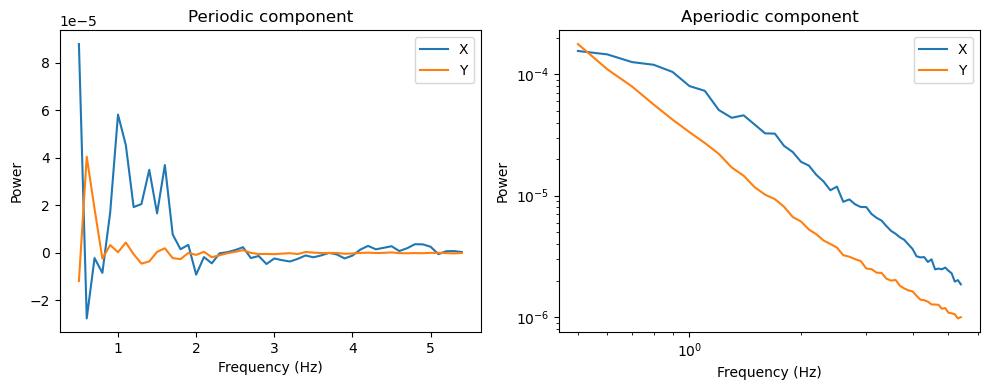

In [13]:
maxf = 50

fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

axes[0].plot(
    gazedata["irasa_out"].freqs[:maxf],
    gazedata["irasa_out"].periodic[0, :maxf],
)
axes[0].plot(
    gazedata["irasa_out"].freqs[:maxf],
    gazedata["irasa_out"].periodic[1, :maxf],
)
axes[0].set_title("Periodic component")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Power")
axes[0].legend(["X", "Y"])

axes[1].loglog(
    gazedata["irasa_out"].freqs[:maxf],
    gazedata["irasa_out"].aperiodic[0, :maxf],
)
axes[1].loglog(
    gazedata["irasa_out"].freqs[:maxf],
    gazedata["irasa_out"].aperiodic[1, :maxf],
)
axes[1].set_title("Aperiodic component")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power")
axes[1].legend(["X", "Y"])

plt.tight_layout()
plt.show()


## 9. Compute ocular activity measures

Velocity is computed from Euclidean displacement between consecutive gaze samples:

```text
velocity = displacement × sampling_rate
```

Because the gaze data are in radians, velocity is expressed in `rad/s`.

For fixation data, robust velocity summaries such as median velocity and the 95th percentile are often more useful than the raw maximum.


In [ ]:
fs = int(round(gazedata["fs"]))

gaze_results = ocular_activity_measures(
    raweyes[0, :],
    raweyes[1, :],
    sampling_rate=fs,
    savgol_window=51,
)

summary_keys = [
    "velocity",
    "mean_velocity",
    "median_velocity",
    "sd_velocity",
    "p95_velocity",
    "dispersion_x",
    "dispersion_y",
    "radial_dispersion",
    "bcea",
]

pd.DataFrame([{key: gaze_results[key] for key in summary_keys}]).T.rename(
    columns={0: "value"}
)


KeyError: 'rms_velocity'

## 10. Visualise gaze velocity

This plot shows the smoothed gaze velocity over a short time window.

For fixation data, the signal should usually contain a low baseline with intermittent transient events. These events may correspond to microsaccades, small corrective saccades, or short instability periods.


In [ ]:
vel = gaze_results["velocity"]
t = np.arange(len(vel)) / fs

start_sec = 15
end_sec = 20

in1 = int(start_sec * fs)
in2 = int(end_sec * fs)

plt.figure(figsize=(10, 4))
plt.plot(t[in1:in2], vel[in1:in2])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (rad/s)")
plt.title("Gaze velocity during fixation")
plt.tight_layout()
plt.show()


## 11. Detect transient velocity peaks

The peak detector identifies suprathreshold velocity events using a robust background-noise estimate.

The detector:

1. estimates a robust velocity threshold,
2. identifies suprathreshold segments,
3. merges nearby segments,
4. extracts one peak per event.

These are best interpreted as **microsaccade-like velocity transients**, not definitive microsaccades unless additional criteria are added, such as amplitude limits and binocular consistency.


In [ ]:
peaks, threshold, above, segments = detect_velocity_peaks(
    gaze_results["velocity"],
    fs=fs,
    threshold_factor=6,
    min_duration_ms=2,
    merge_gap_ms=10,
)

print("Detected peaks:", len(peaks))
print("Threshold:", threshold)


## 12. Visualise detected peaks

This plot overlays the detected velocity peaks on the continuous velocity signal.

The dashed line shows the detection threshold.


In [ ]:
start_sec = 15
end_sec = 20

in1 = int(start_sec * fs)
in2 = int(end_sec * fs)

peak_mask = (peaks >= in1) & (peaks < in2)
peaks_win = peaks[peak_mask]

plt.figure(figsize=(10, 4))
plt.plot(t[in1:in2], vel[in1:in2], label="velocity")
plt.plot(t[peaks_win], vel[peaks_win], "ro", label="detected peaks")
plt.axhline(threshold, color="k", linestyle="--", label="threshold")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (rad/s)")
plt.title("Detected velocity peaks")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Compute peak statistics

The peak statistics describe the density, amplitude, and temporal organisation of detected events.

Useful measures include:

- `peak_rate_hz`: event rate per second,
- `median_peak_amp`: typical event magnitude,
- `median_ipi_sec`: typical spacing between events,
- `cv_ipi`: burstiness or irregularity of event timing,
- `ipi_entropy`: heterogeneity of inter-peak interval distribution.


In [ ]:
peak_stats = compute_peak_statistics(
    peaks,
    velocity=gaze_results["velocity"],
    fs=fs,
    n_bins="auto",
)

scalar_stats = {
    key: value
    for key, value in peak_stats.items()
    if np.isscalar(value)
}

pd.DataFrame([scalar_stats]).T.rename(columns={0: "value"})


## 14. Visualise the inter-peak interval distribution

Inter-peak intervals quantify the time between detected ocular events.

The log-transformed distribution is useful because event spacing is often highly skewed: many short intervals may occur during bursts, while longer intervals reflect quieter fixation periods.


In [ ]:
ipi_sec = peak_stats["ipi_sec"]
log_ipi = peak_stats["log_ipi"]

plt.figure(figsize=(7, 4))
plt.hist(log_ipi, bins=20)
plt.xlabel("log10 inter-peak interval (s)")
plt.ylabel("Count")
plt.title("Distribution of event timing")
plt.tight_layout()
plt.show()


## 15. Visualise peak amplitude distribution

The peak amplitude distribution describes the magnitude of detected velocity events.

For fixation data, this distribution is often right-skewed: many small events and a smaller number of larger corrective movements.


In [ ]:
peak_amplitudes = peak_stats["peak_amplitudes"]

plt.figure(figsize=(7, 4))
plt.hist(peak_amplitudes, bins=30)
plt.xlabel("Peak velocity amplitude (rad/s)")
plt.ylabel("Count")
plt.title("Distribution of peak amplitudes")
plt.tight_layout()
plt.show()


## 16. Suggested group-level outputs

For group comparisons, the following features are useful starting points.

### Continuous ocular activity

- median velocity,
- 95th percentile velocity,
- RMS displacement,
- radial dispersion,
- BCEA.

### Event-based ocular activity

- peak rate,
- median peak amplitude,
- 95th percentile peak amplitude,
- median inter-peak interval,
- coefficient of variation of inter-peak intervals,
- entropy of log inter-peak intervals.

These measures capture complementary aspects of fixation behaviour: tonic instability, transient bursts, event magnitude, and temporal irregularity.
